In [1]:
# 导入pandas库，这是我们数据分析的瑞士军刀
import pandas as pd

# --- 1. 加载所有核心及推荐的CSV文件 ---
# 为了方便，请确保所有CSV文件都和你的Jupyter Notebook在同一个文件夹下

print("开始加载数据...")
customers = pd.read_csv('olist_customers_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv')
items = pd.read_csv('olist_order_items_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
translation = pd.read_csv('product_category_name_translation.csv')
print("数据加载完毕！")

# --- 2. 逐一合并数据表，构建分析宽表 ---
# 我们的合并策略是以 orders 表为中心，因为订单是连接用户和商品的核心

# 第一步：将订单表(orders)与订单商品明细表(items)合并
# 使用 'left' 合并，保留所有订单信息，即使某些订单可能没有商品明细（虽然很少见）
df = pd.merge(orders, items, on='order_id', how='left')

# 第二步：将合并后的表与支付信息表(payments)合并
df = pd.merge(df, payments, on='order_id', how='left')

# 第三步：将合并后的表与客户信息表(customers)合并
df = pd.merge(df, customers, on='customer_id', how='left')

# 第四步：将合并后的表与商品信息表(products)合并
df = pd.merge(df, products, on='product_id', how='left')

# 第五步：将合并后的表与商品品类英文翻译表(translation)合并
df = pd.merge(df, translation, on='product_category_name', how='left')

print("所有表格已成功合并！")

# --- 3. 查看合并后的成果 ---
print("\n合并后数据表的基本信息：")
df.info()

print("\n合并后数据表的前5行预览：")
print(df.head())

开始加载数据...
数据加载完毕！
所有表格已成功合并！

合并后数据表的基本信息：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118434 entries, 0 to 118433
Data columns (total 31 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       118434 non-null  object 
 1   customer_id                    118434 non-null  object 
 2   order_status                   118434 non-null  object 
 3   order_purchase_timestamp       118434 non-null  object 
 4   order_approved_at              118258 non-null  object 
 5   order_delivered_carrier_date   116360 non-null  object 
 6   order_delivered_customer_date  115037 non-null  object 
 7   order_estimated_delivery_date  118434 non-null  object 
 8   order_item_id                  117604 non-null  float64
 9   product_id                     117604 non-null  object 
 10  seller_id                      117604 non-null  object 
 11  shipping_limit_date            117604 non-null  

In [2]:
# 将所有时间相关列转换为datetime格式
time_cols = ['order_purchase_timestamp', 'order_approved_at', 
             'order_delivered_carrier_date', 'order_delivered_customer_date', 
             'order_estimated_delivery_date']

for col in time_cols:
    df[col] = pd.to_datetime(df[col])

# 验证转换是否成功
print("\n转换时间格式后的数据类型：")
df.info()


转换时间格式后的数据类型：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118434 entries, 0 to 118433
Data columns (total 31 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       118434 non-null  object        
 1   customer_id                    118434 non-null  object        
 2   order_status                   118434 non-null  object        
 3   order_purchase_timestamp       118434 non-null  datetime64[ns]
 4   order_approved_at              118258 non-null  datetime64[ns]
 5   order_delivered_carrier_date   116360 non-null  datetime64[ns]
 6   order_delivered_customer_date  115037 non-null  datetime64[ns]
 7   order_estimated_delivery_date  118434 non-null  datetime64[ns]
 8   order_item_id                  117604 non-null  float64       
 9   product_id                     117604 non-null  object        
 10  seller_id                      117604 non-null  objec

In [3]:
# 提取年、月、星期、小时等信息
df['purchase_year'] = df['order_purchase_timestamp'].dt.year
df['purchase_month'] = df['order_purchase_timestamp'].dt.month
df['purchase_dayofweek'] = df['order_purchase_timestamp'].dt.dayofweek # 周一=0, 周日=6
df['purchase_hour'] = df['order_purchase_timestamp'].dt.hour

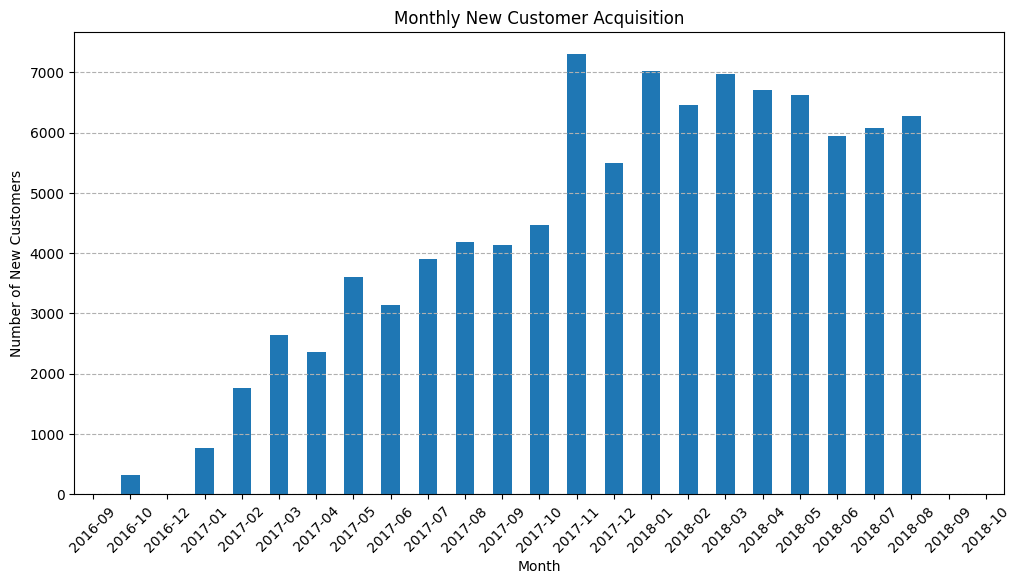

In [4]:
# 导入可视化库
import matplotlib.pyplot as plt
import seaborn as sns

# --- 计算每月新增用户数 ---

# 1. 找到每个用户的首次购买时间
# 我们按 customer_unique_id 分组，然后取每组中最小的购买时间
df_first_purchase = df.groupby('customer_unique_id')['order_purchase_timestamp'].min().reset_index()
df_first_purchase.columns = ['customer_unique_id', 'first_purchase_time']

# 2. 从首次购买时间中提取月份信息
df_first_purchase['first_purchase_month'] = df_first_purchase['first_purchase_time'].dt.to_period('M')

# 3. 按月份统计新增用户数
monthly_new_customers = df_first_purchase.groupby('first_purchase_month')['customer_unique_id'].count()

# --- 可视化：展示每月新增用户趋势 ---

plt.figure(figsize=(12, 6))
monthly_new_customers.plot(kind='bar')
plt.title('Monthly New Customer Acquisition')
plt.xlabel('Month')
plt.ylabel('Number of New Customers')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')
plt.show()

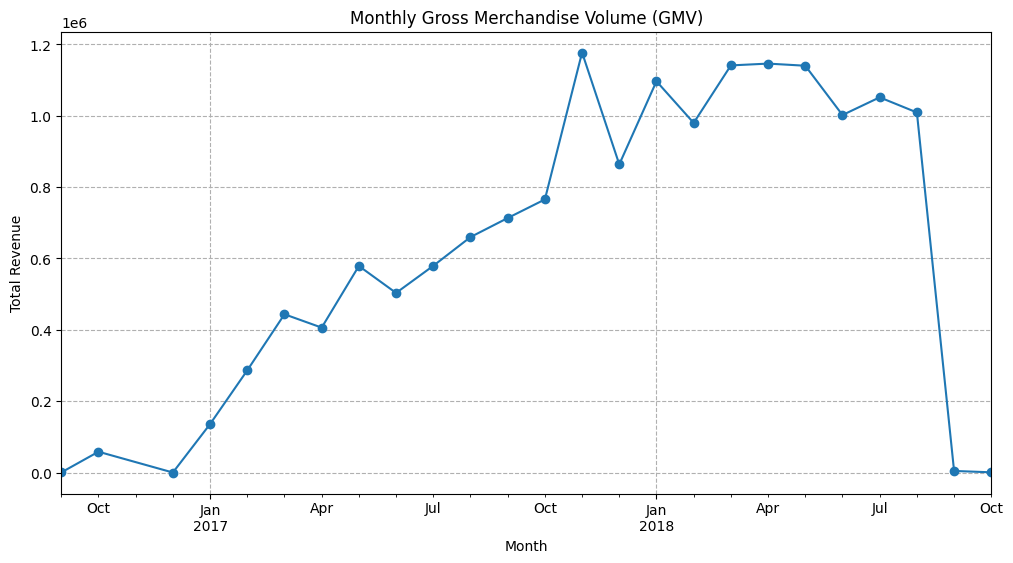

In [5]:
# --- 计算月度总收入 (GMV) ---

# 1. 创建一张以“订单”为最小单位的表，并提取关键信息
# 我们按 order_id 分组，并取该订单的支付金额和购买时间
# .first() 确保每个订单只取一次，避免重复计算
df_orders_revenue = df.groupby('order_id')[['order_purchase_timestamp', 'payment_value', 'customer_state']].first().reset_index()

# 2. 从购买时间中提取月份信息
df_orders_revenue['purchase_month'] = df_orders_revenue['order_purchase_timestamp'].dt.to_period('M')

# 3. 按月份统计总收入
monthly_revenue = df_orders_revenue.groupby('purchase_month')['payment_value'].sum()

# --- 可视化：展示月度GMV趋势 ---

plt.figure(figsize=(12, 6))
monthly_revenue.plot(kind='line', marker='o')
plt.title('Monthly Gross Merchandise Volume (GMV)')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.grid(True, linestyle='--')
plt.show()

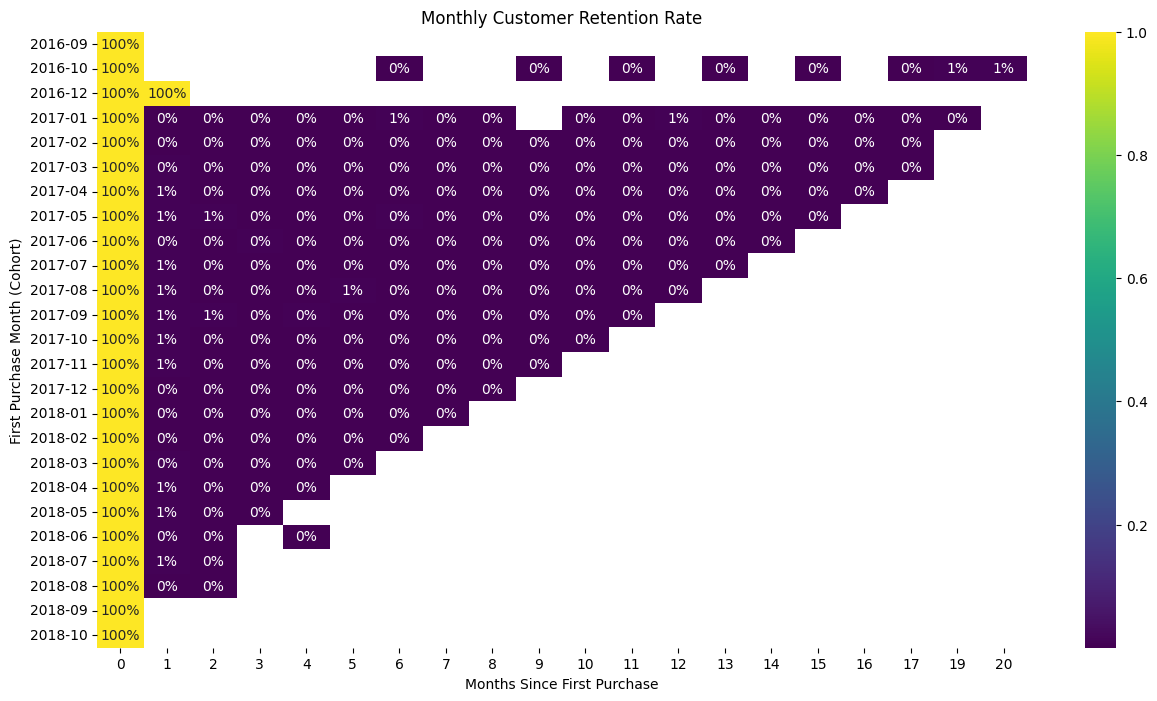

In [6]:
import numpy as np # 我们会用到numpy来处理数据

# --- 同期群分析 (Cohort Analysis) ---

# 我们需要给每个订单，标记上这个订单的客户是哪个“同期群”的
# df_first_purchase 表里有每个客户的首次购买月份，我们把它合并回主表
df = pd.merge(df, df_first_purchase, on='customer_unique_id')

# --- 1. 计算每个订单距离用户首次购买的月份差 ---

# 获取订单的月份
df['purchase_month_dt'] = df['order_purchase_timestamp'].dt.to_period('M')

# 获取用户首次购买的月份 (我们之前计算过)
df['first_purchase_month'] = df['first_purchase_time'].dt.to_period('M')

# 计算月份差，即“同群期索引” (Cohort Index)
# 这代表用户在完成首次购买后的第N个月又进行了购买
df['cohort_index'] = (df['purchase_month_dt'].dt.year - df['first_purchase_month'].dt.year) * 12 + \
                    (df['purchase_month_dt'].dt.month - df['first_purchase_month'].dt.month)

# --- 2. 构建同期群数据透视表 ---

# 按“首次购买月份”和“同群期索引”分组，计算每组中的独立用户数
cohort_data = df.groupby(['first_purchase_month', 'cohort_index'])['customer_unique_id'].nunique().reset_index()

# 将数据转换为数据透视表
cohort_pivot = cohort_data.pivot_table(index='first_purchase_month',
                                     columns='cohort_index',
                                     values='customer_unique_id')

# --- 3. 计算留存率 ---

# 同期群的初始用户数（即第0个月的用户数）
cohort_size = cohort_pivot.iloc[:, 0]

# 将同群期用户数除以初始用户数，得到留存率
# 我们使用.divide()方法，并指定按行(axis=0)进行操作
retention_matrix = cohort_pivot.divide(cohort_size, axis=0)

# --- 4. 可视化：用热力图展示留存率 ---

plt.figure(figsize=(15, 8))
# 使用Seaborn的热力图函数，annot=True表示在格内显示数值，fmt='.0%'表示格式化为百分比
sns.heatmap(retention_matrix, annot=True, fmt='.0%', cmap='viridis')
plt.title('Monthly Customer Retention Rate')
plt.xlabel('Months Since First Purchase')
plt.ylabel('First Purchase Month (Cohort)')
plt.show()

中文字体设置完毕。


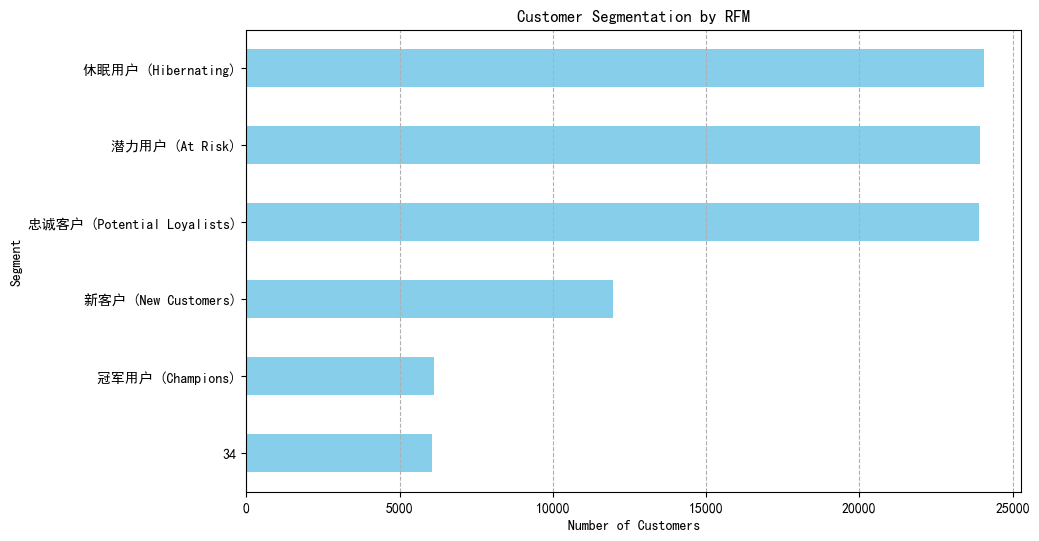

In [8]:
# --- RFM 用户价值分层分析 ---



# 解决matplotlib中文显示问题的代码

import matplotlib.pyplot as plt

# 尝试寻找系统中可用的中文字体
try:
    # 优先使用黑体
    plt.rcParams['font.sans-serif'] = ['SimHei'] 
except Exception as e:
    try:
        # 如果没有黑体，尝试微软雅黑
        plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
    except Exception as e:
        try:
            # 再尝试其他系统默认字体
            plt.rcParams['font.sans-serif'] = ['sans-serif']
        except Exception as e:
            print("未找到可用的中文字体，请检查您的系统字体配置。")

# 解决负号显示问题
plt.rcParams['axes.unicode_minus'] = False 

print("中文字体设置完毕。")



# 1. 确定分析的“快照”日期
# 我们假设分析的日期是数据中最后一个订单日期的后一天
snapshot_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# 2. 计算每个用户的 R, F, M 值
# 我们需要使用之前创建的以“订单”为最小单位的表 df_orders_revenue
# 为了计算F值，我们需要将customer_unique_id添加进去
df_orders_customer = pd.merge(df_orders_revenue, 
                              df[['order_id', 'customer_unique_id']].drop_duplicates(), 
                              on='order_id')

# 计算RFM指标
rfm_data = df_orders_customer.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days, # Recency
    'order_id': 'count', # Frequency
    'payment_value': 'sum' # Monetary
}).reset_index()

# 重命名列名
rfm_data.columns = ['customer_unique_id', 'Recency', 'Frequency', 'Monetary']

# 3. 为 R, F, M 指标打分 (使用四分位数)
# 分数越高，代表价值越高
r_labels = range(4, 0, -1) # Recency越小越好，所以分数要倒序
f_labels = range(1, 5)
m_labels = range(1, 5)

# 使用qcut进行等频分箱
rfm_data['R_Score'] = pd.qcut(rfm_data['Recency'], q=4, labels=r_labels, duplicates='drop')
rfm_data['F_Score'] = pd.qcut(rfm_data['Frequency'].rank(method='first'), q=4, labels=f_labels, duplicates='drop')
rfm_data['M_Score'] = pd.qcut(rfm_data['Monetary'], q=4, labels=m_labels, duplicates='drop')

# 4. 合并RFM分数并进行用户分层
rfm_data['RFM_Score'] = rfm_data['R_Score'].astype(str) + rfm_data['F_Score'].astype(str) + rfm_data['M_Score'].astype(str)

# 定义用户分层规则
# 注意：由于本案例中F值普遍很低，传统8分法可能不完全适用，但我们依然可以用它来划分
segment_map = {
    r'[1-2][1-2]': '休眠用户 (Hibernating)',
    r'[1-2][3-4]': '潜力用户 (At Risk)',
    r'[3-4]1': '新客户 (New Customers)',
    r'41': '高潜力新客 (Promising New)',
    r'[3-4][2-3]': '忠诚客户 (Potential Loyalists)',
    r'4[2-4]': '冠军用户 (Champions)' # 包含42, 43, 44
}

rfm_data['Segment'] = rfm_data['R_Score'].astype(str) + rfm_data['F_Score'].astype(str)
rfm_data['Segment'] = rfm_data['Segment'].replace(segment_map, regex=True)


# --- 5. 可视化：查看各类用户占比 ---
segment_counts = rfm_data['Segment'].value_counts().sort_values(ascending=True)

plt.figure(figsize=(10, 6))
segment_counts.plot(kind='barh', color='skyblue')
plt.title('Customer Segmentation by RFM')
plt.xlabel('Number of Customers')
plt.ylabel('Segment')
plt.grid(axis='x', linestyle='--')
plt.show()

平台Top 10畅销品类 (按销售额):
product_category_name_english
health_beauty            1297490.77
watches_gifts            1253143.30
bed_bath_table           1092551.02
sports_leisure           1023996.34
computers_accessories     942277.57
furniture_decor           765093.89
housewares                666587.00
cool_stuff                662309.49
auto                      616752.51
garden_tools              518217.54
Name: price, dtype: float64


C:\Users\79926\AppData\Local\Temp\ipykernel_5404\2719693609.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_10_categories.index, x=top_10_categories.values, palette='viridis')


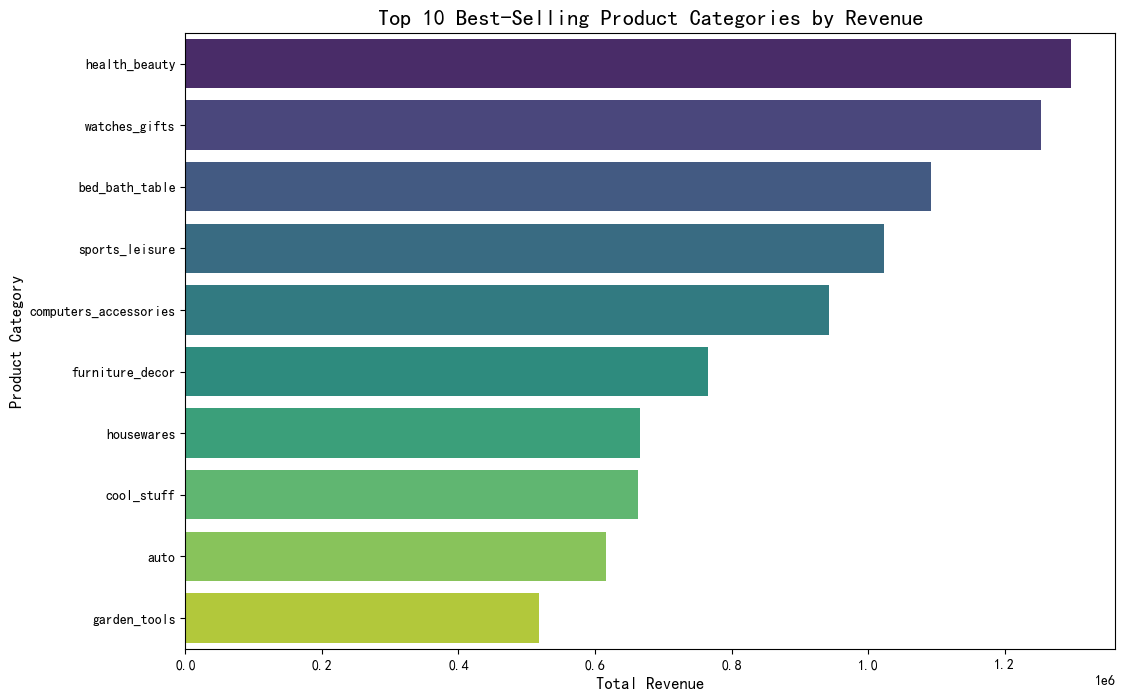

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 计算各商品品类的总销售额 ---

# 按英文品类名分组，并对商品价格求和
# .dropna() 用于去除没有品类名的数据
category_revenue = df.dropna(subset=['product_category_name_english']).groupby('product_category_name_english')['price'].sum()

# 按销售额降序排序，并选取前10名
top_10_categories = category_revenue.sort_values(ascending=False).head(10)

print("平台Top 10畅销品类 (按销售额):")
print(top_10_categories)

# --- 可视化：Top 10畅销品类条形图 ---

plt.figure(figsize=(12, 8))
# 使用Seaborn绘制水平条形图，便于阅读品类名称
sns.barplot(y=top_10_categories.index, x=top_10_categories.values, palette='viridis')

plt.title('Top 10 Best-Selling Product Categories by Revenue', fontsize=16)
plt.xlabel('Total Revenue', fontsize=12)
plt.ylabel('Product Category', fontsize=12)
plt.show()

--- 修正后的用户分层结果 ---
Segment
休眠用户 (Hibernating)        24081
高危用户 (At Risk)            23940
潜力用户 (Potential)          12047
需要关注 (Needs Attention)    11964
忠诚客户 (Loyalists)          11953
冠军用户 (Champions)           6140
41                         5971
Name: count, dtype: int64


C:\Users\79926\AppData\Local\Temp\ipykernel_5404\3649173985.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_categories.reset_index(), y='product_category_name_english', x='price', palette='viridis')


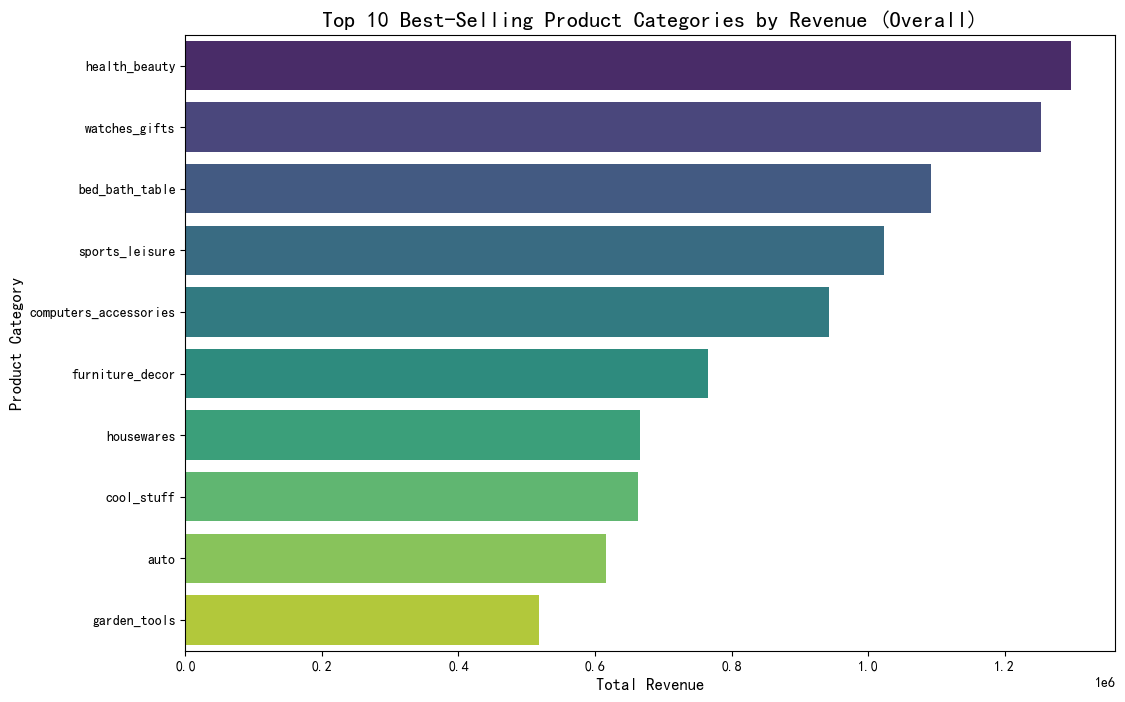

C:\Users\79926\AppData\Local\Temp\ipykernel_5404\3649173985.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_champion_categories.reset_index(), y='product_category_name_english', x='price', palette='plasma')


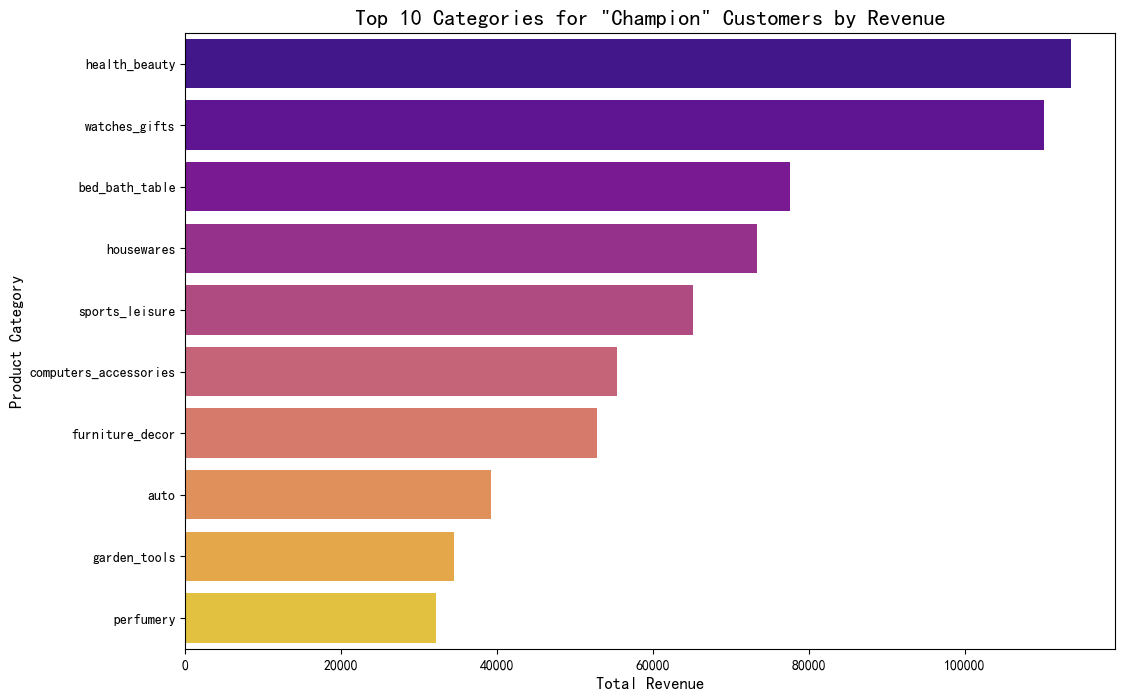

In [12]:
# --------------------【修正并整合后的最终代码】--------------------

import matplotlib.pyplot as plt
import seaborn as sns

# --- 任务四 (修正版): 用RFM模型对用户进行价值分层 ---

# 1. 确定分析的“快照”日期 (代码不变)
snapshot_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# 2. 计算每个用户的 R, F, M 值 (代码不变)
df_orders_customer = pd.merge(df_orders_revenue, 
                              df[['order_id', 'customer_unique_id']].drop_duplicates(), 
                              on='order_id')
rfm_data = df_orders_customer.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'count',
    'payment_value': 'sum'
}).reset_index()
rfm_data.columns = ['customer_unique_id', 'Recency', 'Frequency', 'Monetary']

# 3. 为 R, F, M 指标打分 (代码不变)
r_labels = range(4, 0, -1)
f_labels = range(1, 5)
m_labels = range(1, 5)
rfm_data['R_Score'] = pd.qcut(rfm_data['Recency'], q=4, labels=r_labels, duplicates='drop')
rfm_data['F_Score'] = pd.qcut(rfm_data['Frequency'].rank(method='first'), q=4, labels=f_labels, duplicates='drop')
rfm_data['M_Score'] = pd.qcut(rfm_data['Monetary'], q=4, labels=m_labels, duplicates='drop')

# 4. 【核心修正】调整用户分层规则的优先级
segment_map_corrected = {
    r'44': '冠军用户 (Champions)',   # R=4, F=4 -> Champions
    r'4[2-3]': '忠诚客户 (Loyalists)', # R=4, F=2/3 -> Loyalists
    r'[3-4][3-4]': '潜力用户 (Potential)',# R=3/4, F=3/4 -> Potential
    r'3[1-2]': '需要关注 (Needs Attention)',
    r'[1-2][3-4]': '高危用户 (At Risk)',
    r'[1-2][1-2]': '休眠用户 (Hibernating)'
}
rfm_data['Segment'] = rfm_data['R_Score'].astype(str) + rfm_data['F_Score'].astype(str)
rfm_data['Segment'] = rfm_data['Segment'].replace(segment_map_corrected, regex=True)

print("--- 修正后的用户分层结果 ---")
print(rfm_data['Segment'].value_counts())


# --- 任务五: 畅销商品品类分析 ---

# 1. 分析平台总体的Top 10畅销品类
category_revenue = df.dropna(subset=['product_category_name_english']).groupby('product_category_name_english')['price'].sum()
top_10_categories = category_revenue.sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 8))
# 【绘图代码优化】为了避免未来的警告，使用新的推荐语法
sns.barplot(data=top_10_categories.reset_index(), y='product_category_name_english', x='price', palette='viridis')
plt.title('Top 10 Best-Selling Product Categories by Revenue (Overall)', fontsize=16)
plt.xlabel('Total Revenue', fontsize=12)
plt.ylabel('Product Category', fontsize=12)
plt.show()

# 2. 分析“冠军用户”最爱的Top 10品类
champion_ids = rfm_data[rfm_data['Segment'] == '冠军用户 (Champions)']['customer_unique_id']
df_champions = df[df['customer_unique_id'].isin(champion_ids)]

champion_category_revenue = df_champions.dropna(subset=['product_category_name_english']).groupby('product_category_name_english')['price'].sum()
top_10_champion_categories = champion_category_revenue.sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 8))
# 【绘图代码优化】
sns.barplot(data=top_10_champion_categories.reset_index(), y='product_category_name_english', x='price', palette='plasma')
plt.title('Top 10 Categories for "Champion" Customers by Revenue', fontsize=16)
plt.xlabel('Total Revenue', fontsize=12)
plt.ylabel('Product Category', fontsize=12)
plt.show()

In [15]:
# --- 【最终修正版】导出BI数据源 ---

print("正在生成最终版BI数据源...")

# 1. 创建一张以“订单”为最小单位的表，并提取所有需要的列
# 我们现在加入 'customer_state'
df_orders_revenue = df.groupby('order_id')[['order_purchase_timestamp', 'payment_value', 'customer_state']].first().reset_index()

# 2. 【关键修正】将 'purchase_month' 这一列加回来
# Power BI中的趋势图依赖此列，所以必须保留
# 我们需要先将时间戳列转换为datetime格式，以防万一
df_orders_revenue['order_purchase_timestamp'] = pd.to_datetime(df_orders_revenue['order_purchase_timestamp'])
df_orders_revenue['purchase_month'] = df_orders_revenue['order_purchase_timestamp'].dt.to_period('M')

# 3. 将订单表与customer_unique_id关联
df_orders_customer = pd.merge(df_orders_revenue,
                              df[['order_id', 'customer_unique_id']].drop_duplicates(),
                              on='order_id')

# 4. 导出最终的主数据表
df_orders_customer.to_csv('olist_orders_main.csv', index=False, encoding='utf-8-sig')

# 5. 导出RFM表 (此表无需改动)
rfm_data.to_csv('olist_rfm_segments.csv', index=False, encoding='utf-8-sig')

print("最终版BI数据源已成功导出！现在 olist_orders_main.csv 文件中同时包含 customer_state 和 purchase_month。")

正在生成最终版BI数据源...
最终版BI数据源已成功导出！现在 olist_orders_main.csv 文件中同时包含 customer_state 和 purchase_month。
